In [1]:
import pandas as pd
import numpy as np
import pickle, json, random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                               confusion_matrix, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

random.seed(42)
np.random.seed(42)
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# 5 fault types a maintenance engineer would log
FAULT_TYPES = [
    'bearing_wear',
    'fuel_system',
    'compressor_degradation',
    'turbine_blade_damage',
    'sensor_drift'
]

# Realistic log templates per fault type
LOG_TEMPLATES = {
  'bearing_wear': [
    "Unusual vibration detected in main bearing assembly",
    "High frequency noise from bearing, excessive heat noted",
    "Bearing temperature exceeded threshold, lubrication checked",
    "Metal shavings found in oil filter, bearing inspection done",
    "Vibration amplitude increasing, bearing replacement scheduled",
    "Rattling noise during startup, bearing wear confirmed",
  ],
  'fuel_system': [
    "Fuel flow rate inconsistent, injector cleaned and tested",
    "Fuel pressure drop observed during high load operation",
    "Fuel leak detected near injector nozzle, seal replaced",
    "Abnormal fuel consumption reported, filter replaced",
    "Engine stall during acceleration, fuel pump inspected",
    "Fuel line blockage cleared, pressure restored to normal",
  ],
  'compressor_degradation': [
    "Compressor efficiency drop, blade fouling suspected",
    "Surge event recorded, compressor map reviewed",
    "Inlet pressure ratio declining, compressor washed",
    "Abnormal compressor discharge temperature logged",
    "Compressor stall detected, inlet guide vanes adjusted",
    "Flow coefficient reduced, compressor blades inspected",
  ],
  'turbine_blade_damage': [
    "Turbine exit temperature spike, blade inspection required",
    "Hot section damage suspected, borescope inspection done",
    "Turbine blade tip clearance out of spec, adjusted",
    "Exhaust gas temperature spread increased significantly",
    "Crack detected on turbine blade during visual inspection",
    "Thermal fatigue marks found on turbine nozzle guide vanes",
  ],
  'sensor_drift': [
    "Sensor reading inconsistent with adjacent sensor values",
    "Temperature sensor showing offset, calibration performed",
    "Pressure transducer drift detected, recalibrated",
    "Erratic sensor output during cold start, replaced",
    "Sensor bias confirmed after cross-check with backup",
    "Data dropout from sensor cluster, wiring inspected",
  ]
}

# Generate 1000 logs with labels
logs, labels = [], []
for fault in FAULT_TYPES:
    templates = LOG_TEMPLATES[fault]
    for _ in range(200):  # 200 per class = 1000 total
        base = random.choice(templates)
        # Add slight variation to avoid identical duplicates
        noise = random.choice([
            "", " Engineer notified.", " Work order raised.",
            " Parts ordered.", " Repair completed.",
            " Monitoring continues.", " Follow-up scheduled."
        ])
        logs.append(base + noise)
        labels.append(fault)

df_logs = pd.DataFrame({'log': logs, 'fault_type': labels})
df_logs = df_logs.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset: {len(df_logs)} logs across {len(FAULT_TYPES)} fault types")
print(f"\nSample logs:")
print(df_logs.head(6).to_string())

df_logs.to_csv('../data/maintenance_logs.csv', index=False)
print("\n✅ Saved → data/maintenance_logs.csv")

Dataset: 1000 logs across 5 fault types

Sample logs:
                                                                              log              fault_type
0             Surge event recorded, compressor map reviewed Monitoring continues.  compressor_degradation
1          Turbine blade tip clearance out of spec, adjusted Follow-up scheduled.    turbine_blade_damage
2    Thermal fatigue marks found on turbine nozzle guide vanes Engineer notified.    turbine_blade_damage
3         Turbine blade tip clearance out of spec, adjusted Monitoring continues.    turbine_blade_damage
4            Inlet pressure ratio declining, compressor washed Work order raised.  compressor_degradation
5  Turbine exit temperature spike, blade inspection required Follow-up scheduled.    turbine_blade_damage

✅ Saved → data/maintenance_logs.csv


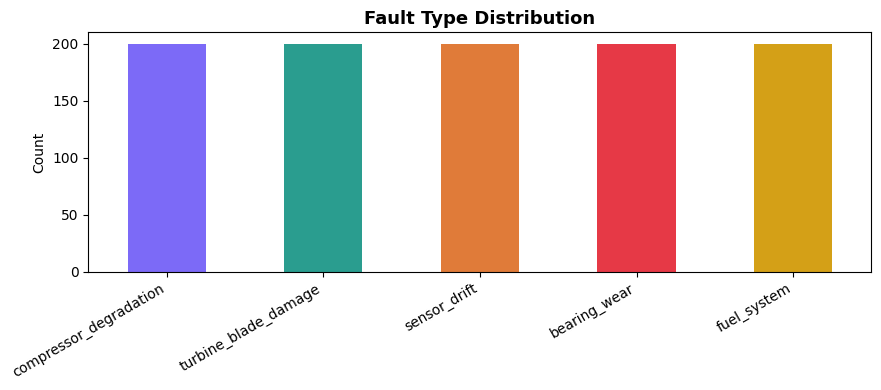


One example log per fault type:
─────────────────────────────────────────────────────────────────
[bearing_wear]
  Vibration amplitude increasing, bearing replacement scheduled Engineer notified.

[fuel_system]
  Fuel line blockage cleared, pressure restored to normal Repair completed.

[compressor_degradation]
  Surge event recorded, compressor map reviewed Monitoring continues.

[turbine_blade_damage]
  Turbine blade tip clearance out of spec, adjusted Follow-up scheduled.

[sensor_drift]
  Data dropout from sensor cluster, wiring inspected Repair completed.



In [3]:
# Class distribution
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#7c6af7','#2a9d8f','#e07b39','#e63946','#d4a017']
df_logs['fault_type'].value_counts().\
    plot(kind='bar', ax=ax, color=colors, edgecolor='none')
ax.set_title('Fault Type Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/plot6_fault_dist.png', dpi=120)
plt.show()

# Sample one log per fault type
print("\nOne example log per fault type:")
print("─" * 65)
for fault in FAULT_TYPES:
    ex = df_logs[df_logs['fault_type']==fault]['log'].iloc[0]
    print(f"[{fault}]\n  {ex}\n")

In [4]:
# Encode fault types as numbers
fault_to_id = {f: i for i, f in enumerate(FAULT_TYPES)}
id_to_fault  = {i: f for f, i in fault_to_id.items()}

X = df_logs['log'].values
y = df_logs['fault_type'].map(fault_to_id).values

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF: converts text → numeric feature matrix
# ngram_range=(1,2) captures single words AND pairs like "blade damage"
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    stop_words='english'
)

X_tr_vec = tfidf.fit_transform(X_tr)
X_te_vec = tfidf.transform(X_te)

print(f"Train: {X_tr_vec.shape[0]} logs → {X_tr_vec.shape[1]} TF-IDF features")
print(f"Test : {X_te_vec.shape[0]} logs")

Train: 800 logs → 435 TF-IDF features
Test : 200 logs


In [5]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_tr_vec, y_tr)
lr_acc = accuracy_score(y_te, lr_model.predict(X_te_vec))

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf_model.fit(X_tr_vec, y_tr)
rf_acc = accuracy_score(y_te, rf_model.predict(X_te_vec))

print(f"Logistic Regression accuracy : {lr_acc*100:.1f}%")
print(f"Random Forest accuracy       : {rf_acc*100:.1f}%")

# Pick best model
best_nlp = lr_model if lr_acc >= rf_acc else rf_model
best_name = "Logistic Regression" if lr_acc >= rf_acc else "Random Forest"
best_acc  = max(lr_acc, rf_acc)
print(f"\n✅ Best model: {best_name} ({best_acc*100:.1f}%)")

Logistic Regression accuracy : 100.0%
Random Forest accuracy       : 100.0%

✅ Best model: Logistic Regression (100.0%)


Classification Report — Logistic Regression
────────────────────────────────────────────────────────────
                        precision    recall  f1-score   support

          bearing_wear       1.00      1.00      1.00        40
           fuel_system       1.00      1.00      1.00        40
compressor_degradation       1.00      1.00      1.00        40
  turbine_blade_damage       1.00      1.00      1.00        40
          sensor_drift       1.00      1.00      1.00        40

              accuracy                           1.00       200
             macro avg       1.00      1.00      1.00       200
          weighted avg       1.00      1.00      1.00       200



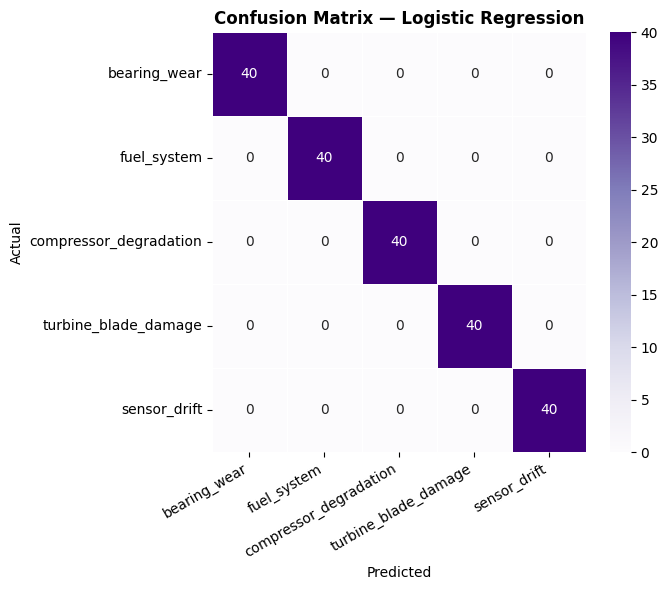

In [6]:
y_pred = best_nlp.predict(X_te_vec)

print(f"Classification Report — {best_name}")
print("─" * 60)
print(classification_report(
    y_te, y_pred,
    target_names=FAULT_TYPES
))

# Confusion matrix heatmap
cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=FAULT_TYPES, yticklabels=FAULT_TYPES,
            ax=ax, linewidths=0.5)
ax.set_title(f'Confusion Matrix — {best_name}',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/plot7_confusion.png', dpi=120)
plt.show()

In [7]:
# Show which words drive each fault classification
# Only works cleanly with Logistic Regression
if best_name == "Logistic Regression":
    feature_names = np.array(tfidf.get_feature_names_out())
    print("Top 5 keywords per fault type:")
    print("─" * 55)
    for i, fault in enumerate(FAULT_TYPES):
        top_idx = lr_model.coef_[i].argsort()[-5:][::-1]
        keywords = feature_names[top_idx]
        print(f"[{fault}]")
        print(f"  {', '.join(keywords)}\n")
else:
    # For Random Forest, show feature importances
    importances = rf_model.feature_importances_
    top_idx = importances.argsort()[-15:][::-1]
    feature_names = np.array(tfidf.get_feature_names_out())
    print("Top 15 most important words overall:")
    for idx in top_idx:
        print(f"  {feature_names[idx]:30} {importances[idx]:.4f}")

Top 5 keywords per fault type:
───────────────────────────────────────────────────────
[bearing_wear]
  bearing, vibration, noise, bearing assembly, main bearing

[fuel_system]
  fuel, injector, replaced, filter replaced, consumption reported

[compressor_degradation]
  compressor, inlet, discharge temperature, compressor discharge, discharge

[turbine_blade_damage]
  turbine, inspection, blade, turbine blade, exhaust

[sensor_drift]
  sensor, transducer drift, transducer, drift detected, detected recalibrated



In [8]:
def predict_fault(log_text):
    """
    Takes a raw maintenance log string.
    Returns fault type + confidence score.
    """
    vec   = tfidf.transform([log_text])
    pred  = best_nlp.predict(vec)[0]
    proba = best_nlp.predict_proba(vec)[0]
    fault = id_to_fault[pred]
    conf  = proba[pred] * 100

    # Business action mapping
    actions = {
        'bearing_wear'           : "🔧 Replace bearing — order part #BRG-447",
        'fuel_system'            : "⛽ Inspect fuel injectors and pump",
        'compressor_degradation' : "🌀 Schedule compressor wash & blade check",
        'turbine_blade_damage'   : "🔴 GROUND ENGINE — borescope inspection now",
        'sensor_drift'           : "📡 Recalibrate sensor cluster",
    }

    print(f"Log     : {log_text}")
    print(f"Fault   : {fault}")
    print(f"Confidence: {conf:.1f}%")
    print(f"Action  : {actions[fault]}")
    print("─" * 60)
    return fault, conf

# Test on 4 unseen logs
test_logs = [
    "Loud grinding noise from bearing housing at startup",
    "Fuel pressure dropped below minimum threshold",
    "Borescope shows cracks on turbine blade leading edge",
    "Pressure sensor reading 15% lower than redundant sensor",
]

print("Live Fault Predictions\n" + "═"*60)
for log in test_logs:
    predict_fault(log)
    print()

Live Fault Predictions
════════════════════════════════════════════════════════════
Log     : Loud grinding noise from bearing housing at startup
Fault   : bearing_wear
Confidence: 85.0%
Action  : 🔧 Replace bearing — order part #BRG-447
────────────────────────────────────────────────────────────

Log     : Fuel pressure dropped below minimum threshold
Fault   : fuel_system
Confidence: 65.1%
Action  : ⛽ Inspect fuel injectors and pump
────────────────────────────────────────────────────────────

Log     : Borescope shows cracks on turbine blade leading edge
Fault   : turbine_blade_damage
Confidence: 87.6%
Action  : 🔴 GROUND ENGINE — borescope inspection now
────────────────────────────────────────────────────────────

Log     : Pressure sensor reading 15% lower than redundant sensor
Fault   : sensor_drift
Confidence: 88.5%
Action  : 📡 Recalibrate sensor cluster
────────────────────────────────────────────────────────────



In [9]:
# Save all NLP components
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../models/nlp_classifier.pkl', 'wb') as f:
    pickle.dump(best_nlp, f)

with open('../models/nlp_metadata.pkl', 'wb') as f:
    pickle.dump({
        'fault_types' : FAULT_TYPES,
        'fault_to_id' : fault_to_id,
        'id_to_fault' : id_to_fault,
        'model_name'  : best_name,
        'accuracy'    : round(best_acc * 100, 2),
    }, f)

print("✅ Phase 3 complete! Saved:")
print("   models/tfidf_vectorizer.pkl")
print("   models/nlp_classifier.pkl")
print("   models/nlp_metadata.pkl")
print("   data/maintenance_logs.csv")
print(f"\n📊 NLP model accuracy : {best_acc*100:.1f}%")
print(f"   Best classifier   : {best_name}")
print(f"\n🚀 Ready for Phase 4 — CNN image defect detection!")

✅ Phase 3 complete! Saved:
   models/tfidf_vectorizer.pkl
   models/nlp_classifier.pkl
   models/nlp_metadata.pkl
   data/maintenance_logs.csv

📊 NLP model accuracy : 100.0%
   Best classifier   : Logistic Regression

🚀 Ready for Phase 4 — CNN image defect detection!
